In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

100%|██████████| 218M/218M [00:01<00:00, 161MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1


In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be set before GPUs are initialized
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    print("GPU is available and active.")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)
else:
  print("No GPU found. Training will run on CPU.")

1 Physical GPUs, 1 Logical GPUs
GPU is available and active.


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt # For later plotting

# Define image dimensions and batch size
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Assuming 'path' is the directory returned by kagglehub.dataset_download
# For 'tongpython/cat-and-dog', the actual images are often in a 'PetImages' subdirectory.
data_dir = os.path.join(path, 'PetImages')
if not os.path.exists(data_dir):
    print(f"'PetImages' directory not found in {path}. Attempting to use {path} directly.")
    data_dir = path

# Filter out non-image files and zero-byte files (a common issue with this dataset)
# This snippet assumes a structure like data_dir/Cat/img.jpg and data_dir/Dog/img.jpg
for class_name in ['Cat', 'Dog']:
    class_path = os.path.join(data_dir, class_name)
    if os.path.exists(class_path):
        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)
            try:
                # Check for zero-byte files
                if os.path.getsize(fpath) == 0:
                    print(f"Removing zero-byte file: {fpath}")
                    os.remove(fpath)
                # Check for non-image files like Thumbs.db
                elif not fname.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
                    print(f"Removing non-image file: {fpath}")
                    os.remove(fpath)
            except OSError as e:
                print(f"Error accessing or removing file {fpath}: {e}")
    else:
        print(f"Warning: Class directory {class_path} not found. Please check dataset path and structure.")

# Load datasets with a validation split
# Using 'inferred' for labels as folder names are 'Cat' and 'Dog'
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Data augmentation (optional but good practice for image classification)
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

# Rescale images and apply VGG-specific preprocessing
preprocess_input = tf.keras.applications.vgg16.preprocess_input

# Build VGG16 base model (pre-trained on ImageNet)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
base_model.trainable = False # Freeze the convolutional base

# Create a new model on top for binary classification
inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False) # Base model in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x) # Add a dropout layer for regularization
outputs = layers.Dense(1, activation='sigmoid')(x) # Binary classification (Cat/Dog)

model = Model(inputs, outputs)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

'PetImages' directory not found in /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1. Attempting to use /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1 directly.
Found 10028 files belonging to 2 classes.
Using 8023 files for training.
Found 10028 files belonging to 2 classes.
Using 2005 files for validation.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 150, 150,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 150, 150)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 150, 150)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 150, 150)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 150, 150,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 150, 150,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 4, 4, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │        513 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
EPOCHS = 20 # You can adjust the number of epochs

print("Starting model training...")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)
print("Model training finished.")

Starting model training...
Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.6556 - loss: 3.9729 - val_accuracy: 0.7332 - val_loss: 2.7701
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.6803 - loss: 3.5241 - val_accuracy: 0.7466 - val_loss: 2.5111
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.6724 - loss: 3.1573 - val_accuracy: 0.7566 - val_loss: 2.3696
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.6898 - loss: 2.9169 - val_accuracy: 0.7541 - val_loss: 2.1054
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.6785 - loss: 2.6203 - val_accuracy: 0.7601 - val_loss: 1.9852
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 22s 86ms/step - accuracy: 0.6794 - loss: 2.4793 - val_accuracy: 0.7541 - val_loss: 1.7804
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.6825 - loss: 2.2860 - val_accuracy: 0.7651 - val_loss: 1.7271
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accurac

In [ ]:
# Summarize training results
print("\n--- Training Results Summary ---")
final_train_loss = history.history['loss'][-1]
final_train_accuracy = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]

print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")


--- Training Results Summary ---
Final Training Loss: 0.7438
Final Training Accuracy: 0.7203
Final Validation Loss: 0.6646
Final Validation Accuracy: 0.7965


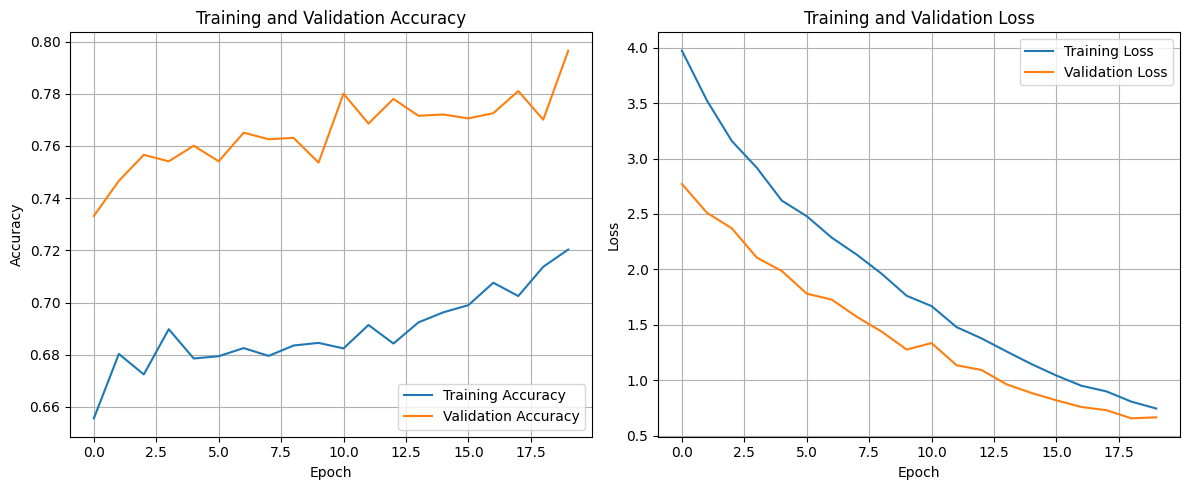

In [ ]:
# Display training plots
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()